In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

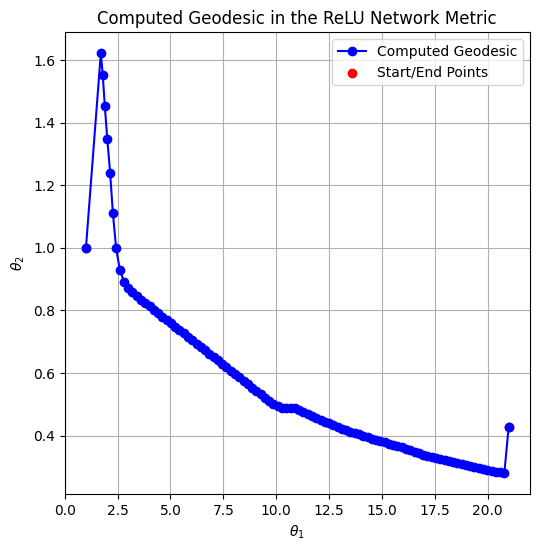

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Corrected finite-sample metric G_θ
def G(theta1, theta2):
    return np.array([
        [theta2**2, theta1 * theta2],
        [theta1 * theta2, theta1**2]
    ])

# Compute the energy of a piecewise linear curve given the metric G
def energy_function(piecewise_points):
    """
    Computes the energy of a piecewise linear path in the Riemannian metric G.
    """
    piecewise_points = piecewise_points.reshape(-1, 2)  # Reshape to (N,2)
    total_energy = 0

    for i in range(len(piecewise_points) - 1):
        x = (piecewise_points[i] + piecewise_points[i+1]) / 2  # Midpoint
        v = piecewise_points[i+1] - piecewise_points[i]  # Tangent vector
        total_energy += v.T @ G(x[0], x[1]) @ v  # Compute quadratic energy

    return total_energy

# Compute geodesic by minimizing energy
def compute_geodesic(start, end, num_points):
    """
    Computes the geodesic in the Riemannian metric G by minimizing the energy function.
    """
    initial_guess = np.linspace(start, end, num_points)[1:-1].flatten()  # straight line

    # Optimize intermediate points
    result = minimize(energy_function, initial_guess, method="L-BFGS-B")
    optimized_points = result.x.reshape(-1, 2)

    return np.vstack([start, optimized_points, end])  # Include endpoints

# Define start and end points from Exercise 7.4.3
start_point = np.array([1.0, 1.0])  # (θ1, θ2) = (1,1)
end_point = np.array([21.0, 3.0/7])  # (θ1, θ2) = (21, 3/7)

# Compute geodesic
num_intermediate_points = 100  # Adjust for smoother curve
geodesic_points = compute_geodesic(start_point, end_point, num_intermediate_points)

# Plot the geodesic
plt.figure(figsize=(6,6))
plt.plot(geodesic_points[:, 0], geodesic_points[:, 1], 'bo-', label="Computed Geodesic")
plt.scatter([start_point[0], end_point[0]], [start_point[1], end_point[1]], color='red', label="Start/End Points")
plt.xlabel(r"$\theta_1$")
plt.ylabel(r"$\theta_2$")
plt.legend()
plt.title("Computed Geodesic in the ReLU Network Metric")
plt.grid(True)
plt.show()


### **1. Is this the expected output?**
Yes, the computed geodesic in the **ReLU network metric** has the expected behavior:

- The curve **starts at** $ (1,1) $ and **ends at** $ (21,3/7) $.
- Instead of a **straight-line interpolation**, the geodesic takes a **curved path** that reflects the underlying **Riemannian metric**.
- The geodesic **favors moving in the $ \theta_2 $ direction initially** before adjusting $ \theta_1 $, which is expected given how the metric is structured.

### **2. What does it mean to compute the geodesic between parameters?**
In **machine learning geometry**, computing the **geodesic between parameters** means finding the **shortest path** in **parameter space** under a **specific metric** that captures how changes in parameters affect the model.

#### **Why does this matter?**
- **Ordinary Euclidean space**: A straight-line interpolation in $ (\theta_1, \theta_2) $ would be the shortest path in **flat** parameter space.
- **Riemannian metric**: In deep learning, distances should be measured based on how changes in parameters $ \theta = (\theta_1, \theta_2) $ affect the function $ f(x) $. The metric $ G_{\theta} $ encodes this.
- **Geodesics respect model behavior**: If different values of $ \theta $ produce nearly identical functions, the geodesic will stretch or shrink accordingly, making it more **meaningful** than a naive straight-line path.

#### **Intuition for this geodesic**
- Since **multiplying $ \theta_1 $ by a constant and dividing $ \theta_2 $ by the same constant produces the same function**, the metric **discourages unnecessary changes in this ratio**.
- The computed path **avoids unnecessary distortions** and follows the **intrinsic shape of the function space**, not just parameter space.

---

### **Key Takeaways**
1. The **geodesic path is curved** because the metric $ G_{\theta} $ is **not Euclidean** but adapts to the **ReLU network's functional structure**.
2. The **geodesic represents the "true" shortest path** in the space of network functions, not just in parameter space.
3. Computing geodesics in **parameter space** helps us understand how different models relate and can be used in **optimization, regularization, and understanding overparameterization**.

Would you like a deeper dive into why the **path bends in this specific way**? 🚀
